In [3]:
%load_ext autoreload
%autoreload 2

import datetime
import sys

import matplotlib.pyplot as plt
import pandas as pd
import pytz

sys.path.append("../../")

from BT.signals import (
    PCAMomentumConfig,
    load_intraday_rate_panel,
    run_pca_momentum_query_backtest,
    run_pca_momentum_vectorized_backtest,
    walk_forward_pca_momentum,
)

NYC = pytz.timezone("America/New_York")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
config = PCAMomentumConfig(
    source="BARCHART_STIRF-RL",
    curve="USD-SOFR-1D-Q12STIRT",
    contract_ranks=list(range(1, 13)),
    loader_freq="30min",
    signal_bar_freq="30min",
    trade_bpv=100_000.0,
)

start = NYC.localize(datetime.datetime(2026, 3, 2, 18, 0))
end = NYC.localize(datetime.datetime(2026, 3, 20, 17, 0))

In [9]:
rate_panel = load_intraday_rate_panel(start=start, end=end, config=config)
walk_forward = walk_forward_pca_momentum(rate_panel, config=config)

display(rate_panel.tail())
display(walk_forward.signal_panel.tail())

DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


READING USD-SOFR-1D-Q12STIRT computed cache...:   0%|          | 0/12 [00:00<?, ?it/s]

,SFR1,SFR2,SFR3,SFR4,SFR5,SFR6,SFR7,SFR8,SFR9,SFR10,SFR11,SFR12
Date,,,,,,,,,,,,
2026-03-20 15:00:00-04:00,3.740175,3.777377,3.783175,3.748861,3.666237,3.552462,3.484467,3.484470,3.510494,3.540754,3.540754,3.540754
2026-03-20 15:30:00-04:00,3.733745,3.765008,3.772465,3.743753,3.665239,3.552860,3.486131,3.487629,3.513107,3.541681,3.541681,3.541681
2026-03-20 16:00:00-04:00,3.733745,3.765008,3.772465,3.743753,3.665239,3.552860,3.486131,3.487629,3.513107,3.541681,3.541681,3.541681
2026-03-20 16:30:00-04:00,3.733745,3.765008,3.772465,3.743753,3.665239,3.552860,3.486131,3.487629,3.513107,3.541681,3.541681,3.541681
2026-03-20 17:00:00-04:00,3.733745,3.765008,3.772465,3.743753,3.665239,3.552860,3.486131,3.487629,3.513107,3.541681,3.541681,3.541681


,SFR1,SFR2,SFR3,SFR4,SFR5,SFR6,SFR7,SFR8,SFR9,SFR10,SFR11,SFR12
Date,,,,,,,,,,,,
2026-03-20 15:00:00-04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-20 15:30:00-04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-20 16:00:00-04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-20 16:30:00-04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-20 17:00:00-04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


{'total_pnl': 0.0, 'sharpe': 0.0, 'max_drawdown': 0.0, 'trade_sides': 0.0}


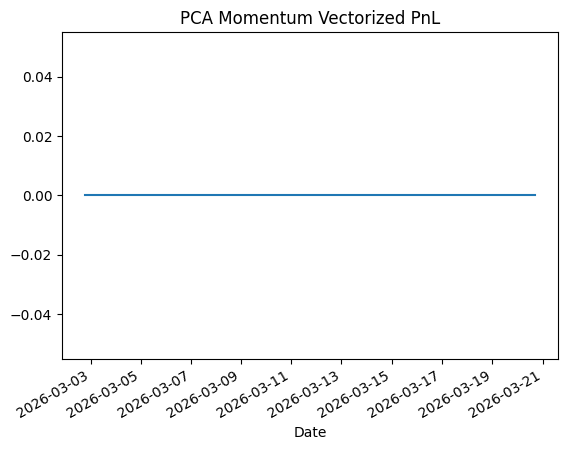

In [6]:
vectorized = run_pca_momentum_vectorized_backtest(
    rate_panel=walk_forward.rate_panel,
    signal_panel=walk_forward.signal_panel,
    config=config,
)

print(vectorized.metrics)
vectorized.cumulative_pnl.plot(title="PCA Momentum Vectorized PnL")
plt.show()


{'total_pnl': 0.0, 'sharpe': 0.0, 'max_drawdown': 0.0, 'trade_sides': 0.0}


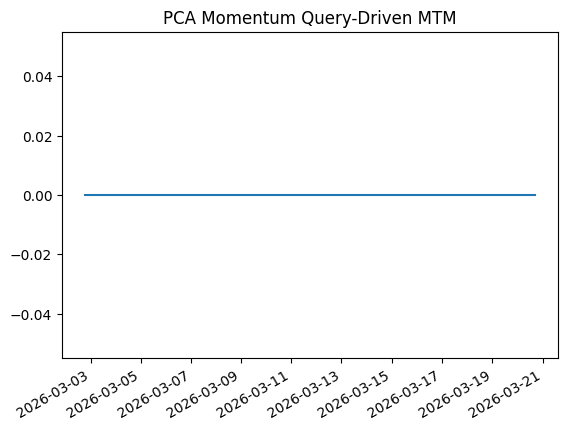

In [7]:
query_backtest = run_pca_momentum_query_backtest(
    walk_forward,
    config=config,
    show_progress=False,
)

print(query_backtest.metrics)
query_backtest.mtm_history.plot(title="PCA Momentum Query-Driven MTM")
plt.show()
